# Submission Pertama: Menyelesaikan Permasalahan Human Resources

- Nama: Naufal Daffa Erlangga
- Email: erlangga.nde@gmail.com
- Id Dicoding: nfldffa

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [3]:
print('Informasi Dataset: ')
df.info()


Informasi Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   i

In [4]:
print('Cek Missing Value: ')
df.isnull().sum()

Cek Missing Value: 


EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

In [5]:
print('Cek Data Duplikat: ')
df.duplicated().sum()

Cek Data Duplikat: 


0

## Exploratory Data Analysis

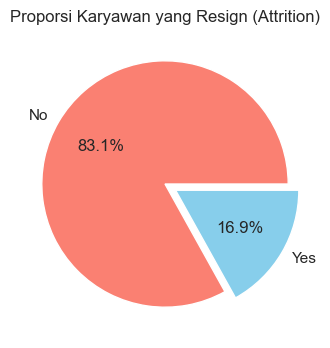

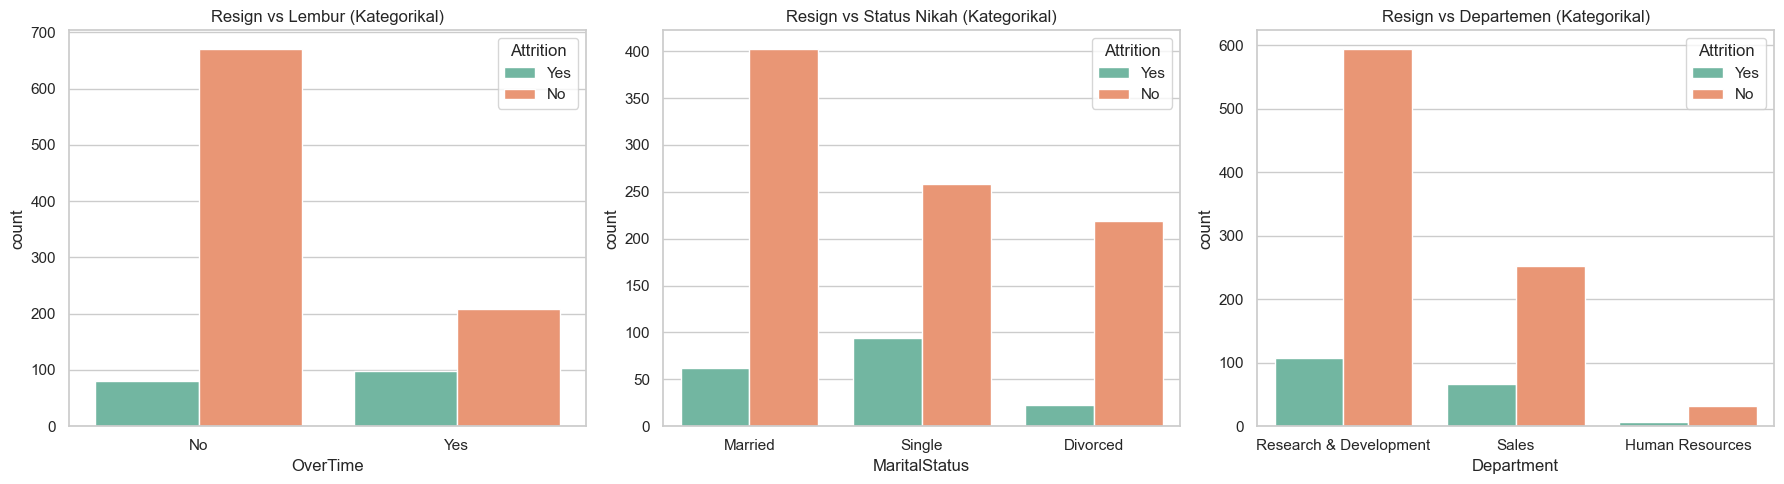

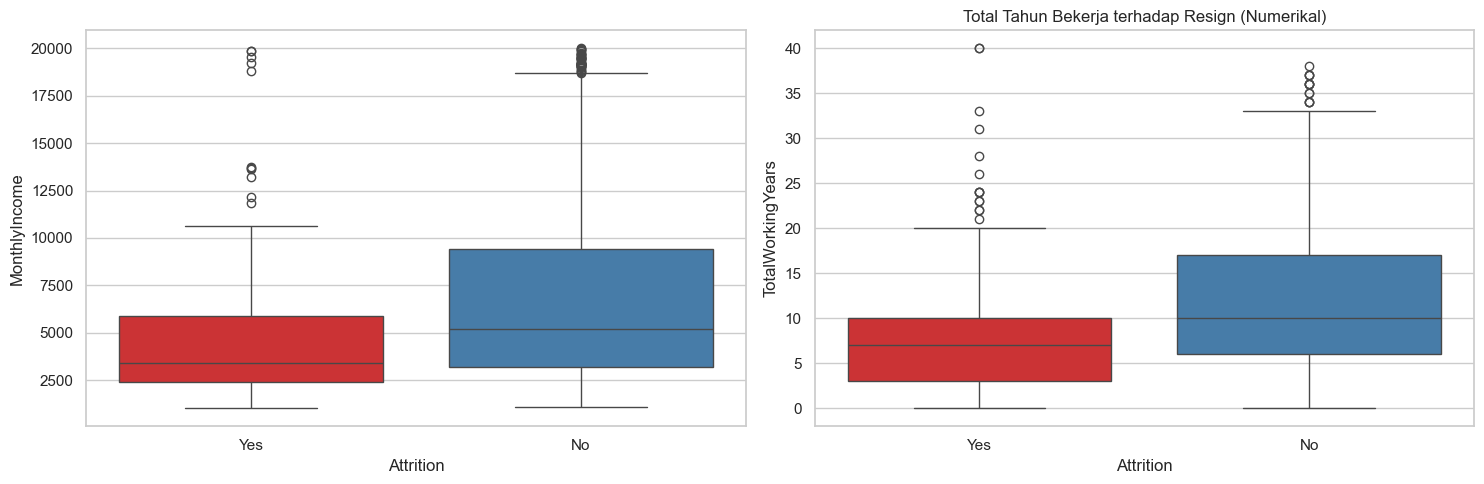

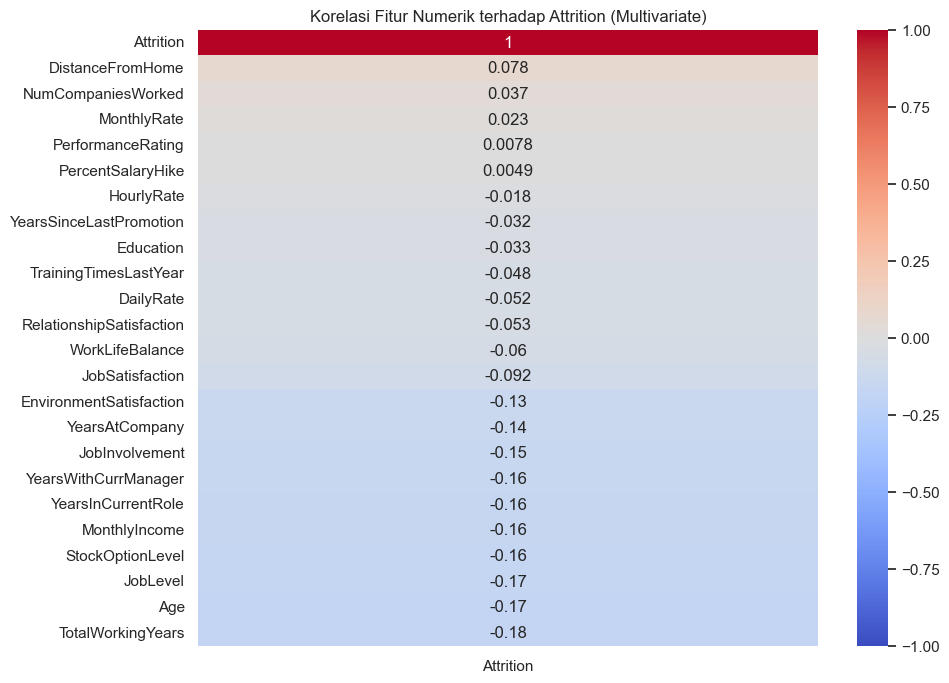

In [6]:
# Siapkan data khusus EDA
df_eda = df.dropna(subset=['Attrition']).copy()

# EDA UNIVARIATE (Melihat proporsi target Attrition)
plt.figure(figsize=(6, 4))
df_eda['Attrition'].map({1.0: 'Yes', 0.0: 'No'}).value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['salmon', 'skyblue'], explode=(0, 0.1)
)
plt.title('Proporsi Karyawan yang Resign (Attrition)')
plt.ylabel('')
plt.show()

# EDA Kategorikal (Hubungan kolom kategori dengan Attrition)
df_eda_cat = df_eda.copy()
df_eda_cat['Attrition'] = df_eda_cat['Attrition'].map({1.0: 'Yes', 0.0: 'No'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df_eda_cat, x='OverTime', hue='Attrition', ax=axes[0], palette='Set2')
axes[0].set_title('Resign vs Lembur (Kategorikal)')

sns.countplot(data=df_eda_cat, x='MaritalStatus', hue='Attrition', ax=axes[1], palette='Set2')
axes[1].set_title('Resign vs Status Nikah (Kategorikal)')

sns.countplot(data=df_eda_cat, x='Department', hue='Attrition', ax=axes[2], palette='Set2')
axes[2].set_title('Resign vs Departemen (Kategorikal)')
plt.tight_layout()
plt.show()

# EDA Numerikal (Hubungan kolom numerik dengan Attrition)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_eda_cat, x='Attrition', y='MonthlyIncome', ax=axes[0], palette='Set1')

sns.boxplot(data=df_eda_cat, x='Attrition', y='TotalWorkingYears', ax=axes[1], palette='Set1')
axes[1].set_title('Total Tahun Bekerja terhadap Resign (Numerikal)')
plt.tight_layout()
plt.show()

# EDA Multivariate (Heatmap Korelasi Antar Fitur Numerik)
plt.figure(figsize=(10, 8))
kolom_numerik = df_eda.select_dtypes(include=['int64', 'float64']).columns
kolom_numerik = [col for col in kolom_numerik if col not in ['EmployeeId', 'StandardHours', 'EmployeeCount']]

korelasi = df_eda[kolom_numerik].corr()

sns.heatmap(korelasi[['Attrition']].sort_values(by='Attrition', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Fitur Numerik terhadap Attrition (Multivariate)')
plt.show()

### Kesimpulan Hasil Eksplorasi Data (EDA)

Dari visualisasi grafik yang udah dibuat di atas, kita dapat beberapa info penting soal alasan kenapa karyawan pada *resign*:

1. **Data Keseluruhan (Univariate):** Dari diagram *pie chart*, terdapat 16,9% karyawan yang *resign* dan 83,1% yang bertahan. Ini menandakan kalau data kita tidak seimbang (*imbalanced*), yang *resign* jauh lebih sedikit.
2. **Faktor Kategori (Kategorikal):** - Karyawan yang sering ditugasin lembur (*OverTime = Yes*) peluang *resign*-nya lebih besar dibanding yang jam kerjanya normal.
   - Karyawan yang statusnya masih *Single* lebih gampang keluar pindah kerja dibandingin yang udah berkeluarga.
   - Walaupun orang R&D jumlahnya paling banyak, tapi karyawan di divisi *Sales* punya persentase *resign* yang lumayan memprihatinkan.
3. **Faktor Angka (Numerikal):** Dari grafik *boxplot*, kelihatan jelas kalau karyawan yang gajinya (*Monthly Income*) kecil dan pengalaman kerjanya (*Total Working Years*) masih sebentar, itu yang jadi langganan *resign*.
4. **Hubungan Antar Faktor (Multivariate/Korelasi):** Dari *heatmap*, kelihatan kalau makin lama orang kerja (*Total Working Years*), makin tua umurnya (*Age*), dan makin tinggi jabatannya (*Job Level*), mereka bakal makin betah dan males buat *resign* (warnanya biru/korelasi negatif). Sebaliknya, jarak rumah ke kantor (*Distance From Home*) ternyata lumayan ngaruh bikin orang kepikiran buat *resign*.

## Data Preparation / Preprocessing

In [7]:
# Bersihin data buat Machine Learning
df_model = df.dropna(subset=['Attrition']).copy()

# Buang kolom yang tidak relevan
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# Pisahin mana Pertanyaan/Fitur (X) dan mana Kunci Jawaban/Target (y)
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# Encoding: Ubah data kategori (teks) jadi angka (0 dan 1) biar bisa dibaca model
X_encoded = pd.get_dummies(X, drop_first=True)

# Bagi data jadi data latih (train) 80% dan data uji (test) 20%
# stratify=y dipakai biar persentase yang resign di data belajar dan data ujian tetep seimbang
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f'Jumlah data latih: {X_train.shape[0]}')
print(f'Jumlah data uji: {X_test.shape[0]}')
print('Data Preprocessing selesai!\n')

Jumlah data latih: 846
Jumlah data uji: 212
Data Preprocessing selesai!



Pada tahap Data Preparation ini, saya membersihkan data dari nilai kosong dan membuang kolom yang tidak relevan seperti `EmployeeId`. Selain itu, saya melakukan *One-Hot Encoding* agar algoritma *Machine Learning* dapat memproses data kategori. Terakhir, data dibagi menjadi 80% data latih (*training*) dan 20% data uji (*testing*) dengan mempertahankan rasio *attrition* menggunakan parameter `stratify`.

## Modeling

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Menghitung rasio untuk menangani data tidak seimbang (Imbalanced Data)
count_stay = (y_train == 0).sum()
count_resign = (y_train == 1).sum()
ratio = count_stay / count_resign

# Inisialisasi XGBoost
# scale_pos_weight membantu model lebih sensitif terhadap karyawan yang akan resign
xgb_model = XGBClassifier(
  n_estimators=100,
  learning_rate=0.1,
  max_depth=5,
  scale_pos_weight=ratio,
  random_state=42,
  use_label_encoder=False,
  eval_metric='logloss'
)

# Melatih model
xgb_model.fit(X_train, y_train)

# Prediksi data ujian
y_pred_xgb = xgb_model.predict(X_test)

## Evaluation

Evaluasi Model XGBoost: 
Akurasi Model: 83.49%

              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90       176
         1.0       0.51      0.50      0.51        36

    accuracy                           0.83       212
   macro avg       0.71      0.70      0.70       212
weighted avg       0.83      0.83      0.83       212



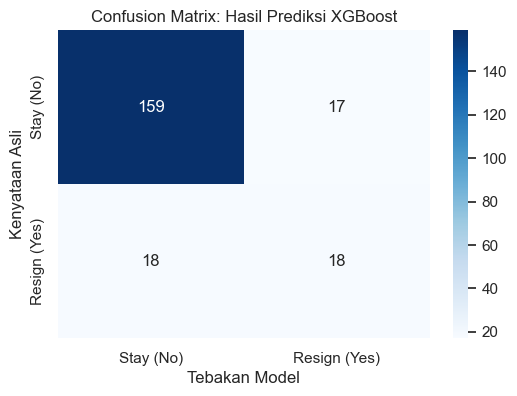

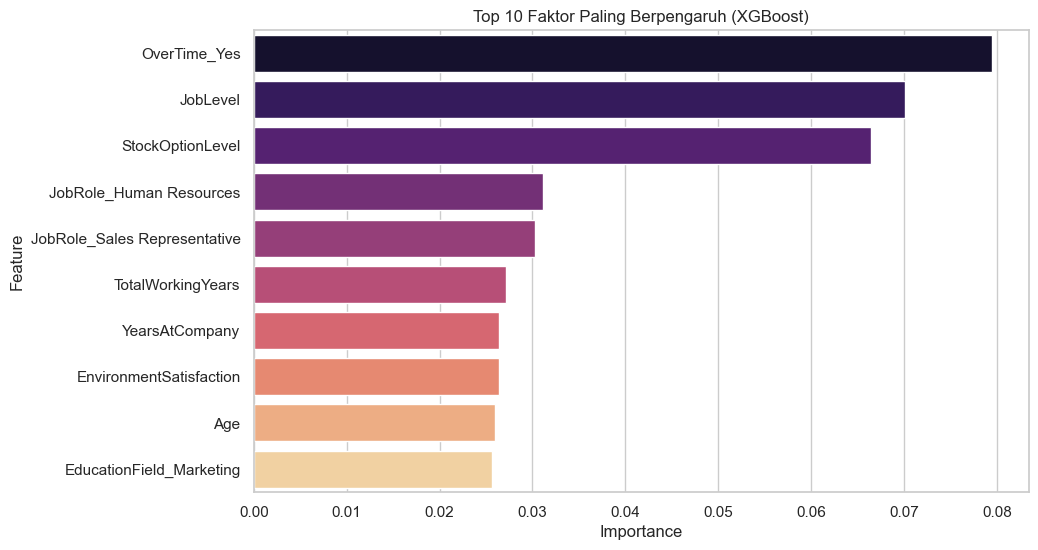

In [9]:
print('Evaluasi Model XGBoost: ')
print(f'Akurasi Model: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%\n')
print(classification_report(y_test, y_pred_xgb))

# Visualisasi Confusion Matrix untuk XGBoost
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (No)', 'Resign (Yes)'], 
            yticklabels=['Stay (No)', 'Resign (Yes)'])
plt.title('Confusion Matrix: Hasil Prediksi XGBoost')
plt.xlabel('Tebakan Model')
plt.ylabel('Kenyataan Asli')
plt.show()

# Visualisasi Feature Importance untuk XGBoost
importances = xgb_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Faktor Paling Berpengaruh (XGBoost)')
plt.show()

In [10]:
import joblib
import os

folder_name = 'model'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

model_columns = list(X_train.columns)

joblib.dump(xgb_model, os.path.join(folder_name, 'model_attrition.pkl'))
joblib.dump(model_columns, os.path.join(folder_name, 'model_columns.pkl'))

print(f"Model tersimpan di dalam folder '{folder_name}'.")

Model tersimpan di dalam folder 'model'.


In [11]:
# Simpan data yang sudah dibersihkan
df_clean = df.dropna(subset=['Attrition']).copy()
df_clean.to_csv('data_karyawan_bersih.csv', index=False)

## Conclusion

Berdasarkan hasil pengujian menggunakan algoritma **XGBoost Classifier** dengan optimasi pada parameter *scale_pos_weight*, berikut adalah analisis mendalam mengenai performa model:

1. **Performa Keseluruhan (Accuracy):**
   Model berhasil mencapai nilai akurasi sebesar **83.49%**. Hal ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mengklasifikasikan status *attrition* karyawan di perusahaan Jaya Jaya Maju secara keseluruhan.

2. **Deteksi Karyawan Resign (Recall & Precision):**
   Model difokuskan untuk mampu mendeteksi kelas minoritas, yaitu karyawan yang memutuskan untuk keluar (kelas 1.0). 
   - **Recall (0.50):** Model memiliki kemampuan untuk mendeteksi 50% dari total karyawan yang sebenarnya akan *resign*. Dalam konteks HR, nilai ini sangat penting karena perusahaan dapat menangkap setengah dari potensi kasus *attrition* untuk segera dilakukan tindakan pencegahan.
   - **Precision (0.51):** Ketika model memprediksi seorang karyawan akan *resign*, tingkat kebenarannya mencapai 51%. Hal ini memberikan keseimbangan agar tim HR tidak terlalu sering melakukan intervensi yang salah sasaran.

3. **Analisis Confusion Matrix:**
   Dari total 212 data uji, model berhasil menebak **18 orang yang benar-benar resign** (True Positive) dan **159 orang yang benar-benar bertahan** (True Negative). Hanya terdapat sedikit kesalahan prediksi, yang menandakan model cukup objektif dalam mengenali pola data.

4. **Faktor Penentu Utama (Feature Importance):**
   Melalui visualisasi *Feature Importance*, ditemukan tiga faktor utama yang paling dominan mempengaruhi keputusan karyawan untuk berhenti bekerja:
   - **OverTime_Yes (Lembur):** Merupakan fitur dengan tingkat kepentingan tertinggi. Beban kerja ekstra di luar jam kantor menjadi pemicu utama kegelisahan karyawan.
   - **JobLevel (Level Pekerjaan):** Jenjang karier di dalam perusahaan sangat mempengaruhi keputusan karyawan untuk tetap loyal atau mencari peluang baru.
   - **StockOptionLevel:** Tingkat kepemilikan saham perusahaan berfungsi sebagai pengikat atau insentif jangka panjang yang efektif untuk mempertahankan karyawan.

### Kesimpulan Strategis:
Model ini telah siap digunakan sebagai alat bantu tim HR untuk melakukan deteksi dini terhadap potensi *attrition*. Fokus utama manajemen sebaiknya diarahkan pada penataan ulang kebijakan jam lembur dan penguatan program pengembangan karier (Job Level) serta insentif saham untuk menurunkan angka *attrition* secara signifikan.